Environtment Set Up

In [2]:
import pyodbc
print([d for d in pyodbc.drivers() if "SQL Server" in d])

['SQL Server', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


In [3]:
from db import run_query

df = run_query(
    "SELECT TOP 5 * FROM notif.vw_ML_L2_CompleteSeries WITH (NOLOCK)",
    env="PROD"
)
df.head()

c:\Users\ana.rangel\Documents\py\ML_project\db.py:55: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


,account,ou_group,period_name,period_date,net_movement,total_debits,total_credits,line_count,active_ou_count,no_movement,running_balance
0,14022,UNV,FEB-2023,2023-02-01,-2000.00,0.00,2000.00,1,1,0,-2000.00
1,14056,UNV,JAN-2023,2023-01-01,4822.18,45577.53,40755.35,30,1,0,4822.18
2,16108,UNV,MAY-2023,2023-05-01,0.00,1059.47,1059.47,4,1,0,0.00
3,14056,UNV,FEB-2023,2023-02-01,78837.21,93458.74,14621.53,118,1,0,83659.39
4,16108,UNV,JUN-2023,2023-06-01,0.00,0.00,0.00,0,0,1,0.00


## Loading the data from prod-db

In [2]:
from data_loader import load_series, series_profile, summarize

df = load_series()
profiles = series_profile (df)
summarize(profiles)

c:\Users\ana.rangel\Documents\py\ML_project\db.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Filas: 15,688 de 415 cuentas (418 excluidas)
Rango: 2023-01 a 2026-07

Cuentas: 415
  24+  (LSTM viable)    :  379  ( 91.3%)
  12-23 (AE simple)     :   14  (  3.4%)
  <12  (solo baseline)  :   22  (  5.3%)

Relación ruido/señal sobre períodos CON movimiento (R13):
  < 0.5  estable      :   65  ( 16.8%)
  0.5-1  manejable    :   48  ( 12.4%)
  1-2    ruidosa      :  205  ( 53.0%)
  > 2    muy ruidosa  :   69  ( 17.8%)

Dispersión (períodos sin movimiento):
  < 25%   densa         :  210  ( 50.6%)
  25-50%  regular       :   39  (  9.4%)
  50-75%  esporádica    :   57  ( 13.7%)
  > 75%   muy esporádica:  109  ( 26.3%)

Series viables para el modelo temporal (>= 24 períodos y <= 50% en cero): 240


## Analisis Exploratorio de Datos

In [3]:
import importlib, data_loader, EDA_profile
importlib.reload(data_loader)
importlib.reload(EDA_profile)

<module 'EDA_profile' from 'c:\\Users\\ana.rangel\\Documents\\py\\ML_project\\EDA_profile.py'>

c:\Users\ana.rangel\Documents\py\ML_project\db.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Filas: 15,688 de 415 cuentas (418 excluidas)
Rango: 2023-01 a 2026-07

--- Longitud de series ---
  24+  (LSTM viable)    :  379  ( 91.3%)
  12-23 (AE simple)     :   14  (  3.4%)
  <12  (solo baseline)  :   22  (  5.3%)

--- Movimiento neto (excluyendo ceros) ---
  n            : 10,024
  mediana      : 2,442
  |p1| - |p99| : 7 - 7,320,554
  asimetría    : -2.9   (>|2| justifica log)

--- Estacionalidad ---
  Mes de mayor actividad : 12
  Mes de menor actividad : 4
  Razón máx/mín          : 10.8x
  -> Estacionalidad relevante: incluir el mes como característica.

--- Relación ruido-señal ---
  < 0.5  estable      :   65  ( 16.8%)
  0.5-1  manejable    :   48  ( 12.4%)
  1-2    ruidosa      :  205  ( 53.0%)
  > 2    muy ruidosa  :   69  ( 17.8%)

--- Períodos sin movimiento ---
  Mediana de la proporción de ceros: 23.3%
  Series con más del 50% en cero   : 165 (39.8%)

Cuentas: 415
  24+  (LSTM viable)    :  379  ( 91.3%)
  12-23 (AE simple)     :   14  (  3.4%)
  <12  (solo baseline)

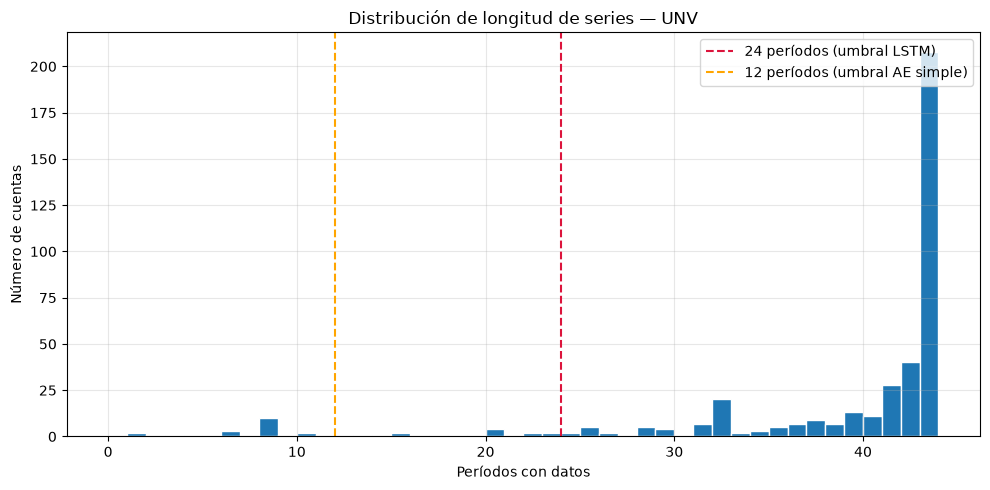

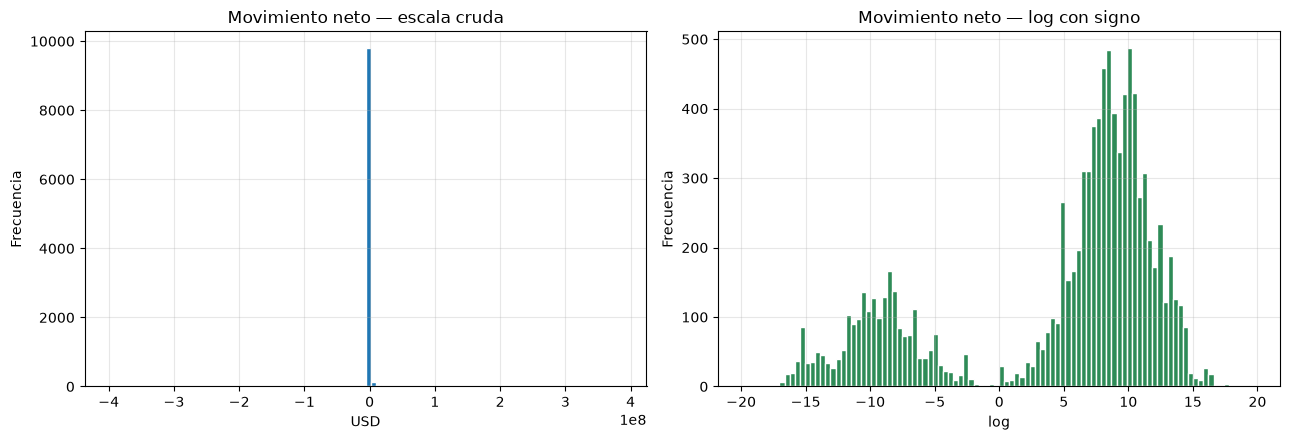

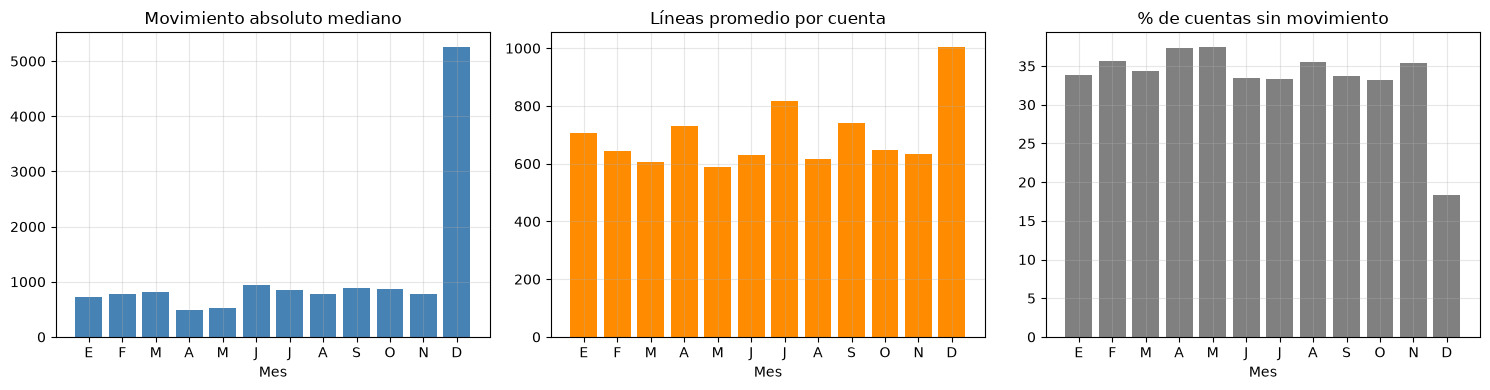

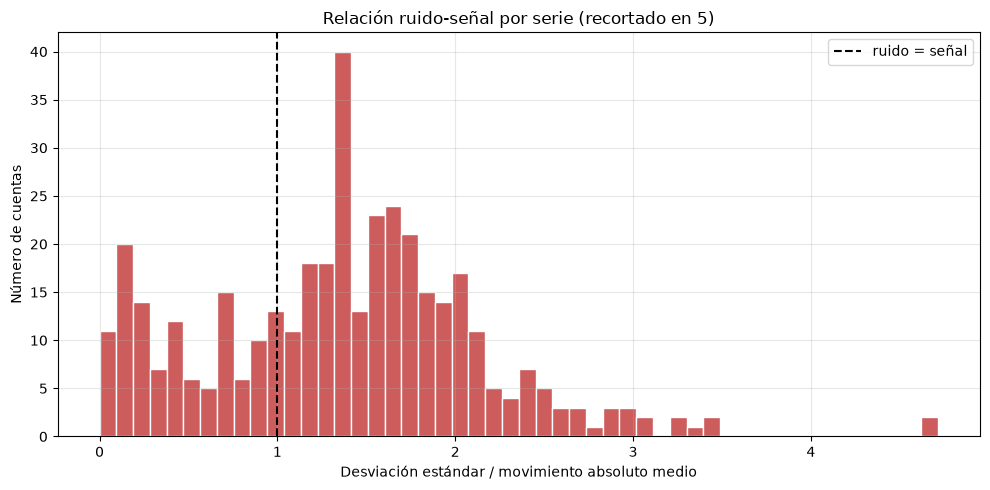

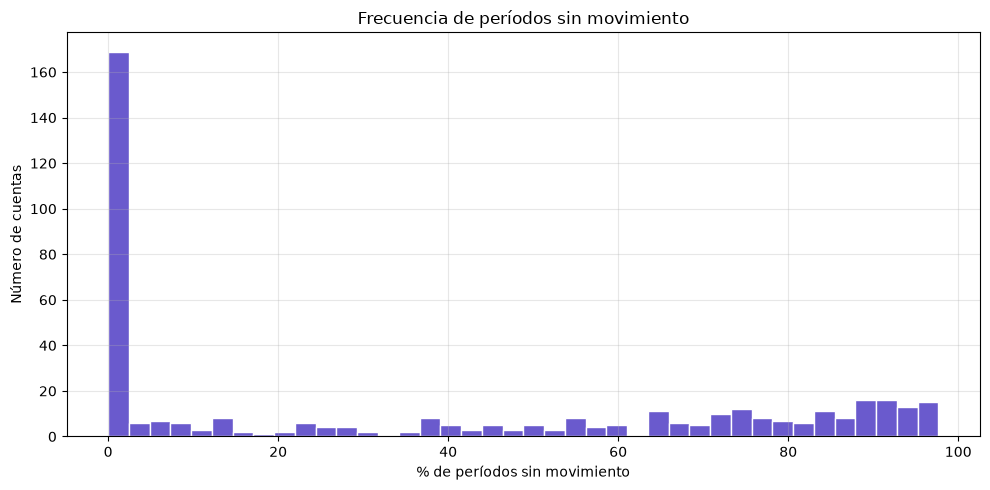

In [4]:
from EDA_profile import run_all
df, profile = run_all()

- Se puede observar que hay dos poblaciones distintas (bimodal): 168 cuentas con casi 0% de ceros y 130 cuentas entre 65% y 100% que se mueven pocas veces al año.
- El grafico logaritmico indica que la mayoría de movimientos son débitos moderados, pero hay créditos muy grandes ocasionales.
- Estacionalidad evidente en diciembre, que es el cierre anual (10,8 veces abril) se debe considerar como una caracteristica del modelo. 

## Baseline

Línea base estadística. Se aplica al historial de cuentas con menos de un año, donde no hay patrón temporal que aprender; se aplica el z-score sobre la propia distribución de la cuenta. 

In [5]:
from baseline import run_baseline
scores, summary = run_baseline(df, profile)

In [6]:
for k, v in summary.items():
    print(f"{k:24s}: {v}")

dense_accounts          : 250
sparse_accounts         : 165
scored_rows             : 15688
flagged_z_gt_3          : 898
flagged_seasonal_gt_3   : 764
top_k                   : 50
materiality_usd         : 1000.0
median_deviation_top_k  : 294625.87


In [7]:
cols = ["account", "period_name", "net_movement", "account_type", "score"]
scores[cols].head(20)

,account,period_name,net_movement,account_type,score
280,14024,MAY-2025,3.852154e+08,dense,24764.745261
279,14024,APR-2025,-3.851970e+08,dense,16482.909965
8170,71525,AUG-2023,1.563342e+06,dense,7732.114648
8167,71525,MAY-2023,1.569703e+06,dense,5239.846403
10643,72402,AUG-2025,3.207503e+05,dense,1848.884464
10620,72402,SEP-2023,2.990997e+05,dense,1702.012528
28,14015,MAY-2025,-1.581176e+06,dense,1574.556119
10622,72402,NOV-2023,2.952368e+05,dense,1549.909601
2230,21035,OCT-2025,2.532303e+05,dense,1445.751784
8494,71541,OCT-2023,-1.007577e+06,dense,1324.315232


In [8]:
print("Filas con puntaje:", scores["score"].notna().sum(), "de", len(scores))
print(scores["score"].describe())

Filas con puntaje: 15688 de 15688
count    15688.000000
mean         8.051302
std        252.843046
min          0.000000
25%          0.000000
50%          0.037563
75%          1.428119
max      24764.745261
Name: score, dtype: float64


In [9]:
scores.head(50)["account_type"].value_counts()

account_type
dense    50
Name: count, dtype: int64

Ranking ignora la materialidad, cambios en baseline y se agrega un nuevo parametro MATERIALITY_USD = 1000 USD (que se debe confirmar con finanzas)

In [10]:
from baseline import run_baseline, balanced_top
import importlib, baseline; importlib.reload(baseline)

<module 'baseline' from 'c:\\Users\\ana.rangel\\Documents\\py\\ML_project\\baseline.py'>

In [11]:
from data_loader import load_series, series_profile
from baseline import run_baseline, balanced_top

df = load_series()
profile = series_profile(df)

c:\Users\ana.rangel\Documents\py\ML_project\db.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Filas: 15,688 de 415 cuentas (418 excluidas)
Rango: 2023-01 a 2026-07


In [12]:
scores, summary = run_baseline(df, profile)
top = balanced_top(scores, k=50, sparse_share=0.3)
top[["account", "period_name", "net_movement", "deviation_usd",
     "account_type", "score_stat", "score"]]

,account,period_name,net_movement,deviation_usd,account_type,score_stat,score
280,14024,MAY-2025,3.852154e+08,3.852077e+08,dense,1925.488260,24764.745261
279,14024,APR-2025,-3.851970e+08,3.852047e+08,dense,1281.566534,16482.909965
8170,71525,AUG-2023,1.563342e+06,1.395957e+05,dense,1563.341850,7732.114648
8167,71525,MAY-2023,1.569703e+06,1.459569e+05,dense,1050.040025,5239.846403
10643,72402,AUG-2025,3.207503e+05,3.202784e+05,dense,320.302460,1848.884464
10620,72402,SEP-2023,2.990997e+05,2.986277e+05,dense,298.465650,1702.012528
28,14015,MAY-2025,-1.581176e+06,1.581176e+06,dense,213.743841,1574.556119
10622,72402,NOV-2023,2.952368e+05,2.947649e+05,dense,272.412680,1549.909601
2230,21035,OCT-2025,2.532303e+05,2.526824e+05,dense,261.150660,1445.751784
8494,71541,OCT-2023,-1.007577e+06,1.028240e+06,dense,190.917719,1324.315232


In [13]:
import importlib, baseline; importlib.reload(baseline)
from baseline import diverse_top, find_reversals

top = diverse_top(scores, k=50, max_per_account=2)
top[["account", "period_name", "net_movement", "deviation_usd",
     "account_type", "score"]].head(25)

print(top["account_type"].value_counts())
print("Cuentas distintas:", top["account"].nunique(), "de", len(top), "alertas")

account_type
dense     35
sparse    15
Name: count, dtype: int64
Cuentas distintas: 35 de 50 alertas


In [14]:
rev = find_reversals(df)
print(f"{len(rev)} pares de reverso")
rev.head(20)

39 pares de reverso


,account,prev_period,period_name,prev_movement,net_movement,amount
280,14024,APR-2025,MAY-2025,-3.851970e+08,3.852154e+08,3.852154e+08
581,14081,DEC-2024,JAN-2025,-9.023639e+06,8.992168e+06,8.992168e+06
110,14017,DEC-2024,JAN-2025,5.034462e+06,-5.034462e+06,5.034462e+06
55,14016,DEC-2023,JAN-2024,4.624723e+06,-4.624723e+06,4.624723e+06
67,14016,DEC-2024,JAN-2025,3.682306e+06,-3.682306e+06,3.682306e+06
79,14016,DEC-2025,JAN-2026,3.652689e+06,-3.652689e+06,3.652689e+06
122,14017,DEC-2025,JAN-2026,3.578020e+06,-3.578020e+06,3.578020e+06
28,14015,APR-2025,MAY-2025,1.581176e+06,-1.581176e+06,1.581176e+06
576,14081,JUL-2024,AUG-2024,1.325732e+06,-1.329238e+06,1.329238e+06
32,14015,AUG-2025,SEP-2025,1.083535e+06,-1.083535e+06,1.083535e+06


In [15]:
import importlib, baseline; importlib.reload(baseline)
from baseline import find_reversals, classify_reversals

rev = classify_reversals(find_reversals(df))
print(rev["category"].value_counts())

rev[rev["category"] == "atipico"][
    ["account", "prev_period", "period_name", "amount"]
]

category
rutina_cuenta    19
atipico          11
rutina_cierre     9
Name: count, dtype: int64


,account,prev_period,period_name,amount
280,14024,APR-2025,MAY-2025,3.852154e+08
922,16005,JUN-2026,JUL-2026,2.500000e+04
3263,23093,MAY-2026,JUN-2026,2.078283e+04
12003,73305,SEP-2025,OCT-2025,6.833200e+03
3581,43118,APR-2025,MAY-2025,6.744490e+03
1054,16108,OCT-2025,NOV-2025,5.000000e+03
471,14075,MAR-2024,APR-2024,4.808360e+03
11159,72605,AUG-2025,SEP-2025,4.159510e+03
12624,74220,NOV-2024,DEC-2024,2.761440e+03
819,15030,JAN-2025,FEB-2025,1.951910e+03


In [16]:
d = df.sort_values(["account", "period_date"]).copy()
d["prev"] = d.groupby("account")["net_movement"].shift(1)
d["prev_period"] = d.groupby("account")["period_name"].shift(1)

opposite = d["net_movement"] * d["prev"] < 0
residual = (d["net_movement"] + d["prev"]).abs()
magnitude = d[["net_movement", "prev"]].abs().max(axis=1)

d["match_pct"] = 1 - residual / magnitude
partial = d[opposite & d["match_pct"].between(0.5, 0.99) & (magnitude > 100000)]

partial[["account", "prev_period", "period_name", "prev",
         "net_movement", "match_pct"]].sort_values("match_pct", ascending=False).head(20)

,account,prev_period,period_name,prev,net_movement,match_pct
2274,21045,DEC-2025,JAN-2026,-342559.86,337791.87,0.986081
1952,21005,DEC-2025,JAN-2026,4865065.96,-4755983.00,0.977578
5461,62340,DEC-2023,JAN-2024,-1364668.20,1332662.85,0.976547
3573,43118,AUG-2024,SEP-2024,119705.66,-116301.06,0.971559
22,14015,OCT-2024,NOV-2024,728835.05,-752335.05,0.968764
1955,21005,MAR-2026,APR-2026,452627.09,-437901.46,0.967466
3532,43117,OCT-2024,NOV-2024,136909.75,-132446.06,0.967397
593,14081,DEC-2025,JAN-2026,-7616154.79,7342679.00,0.964093
1946,21005,JUN-2025,JUL-2025,-2955213.43,3068351.68,0.963127
1949,21005,SEP-2025,OCT-2025,-560686.07,539665.87,0.962510


## Modulo constructor de Caracteristicas

In [5]:
from data_loader import load_series, LoadConfig
from features_L2 import FeatureBuilder, FeatureConfig
import pandas as pd

df = load_series() 
df.head()

c:\Users\ana.rangel\Documents\py\ML_project\db.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Filas: 15,688 de 415 cuentas (418 excluidas)
Rango: 2023-01 a 2026-07


,account,ou_group,period_name,period_date,net_movement,total_debits,total_credits,line_count,active_ou_count,no_movement,running_balance
0,14015,UNV,JAN-2023,2023-01-01,2181182.60,4736510.17,2555327.57,16,1,0,2181182.60
1,14015,UNV,FEB-2023,2023-02-01,-1880447.62,3347079.19,5227526.81,17,1,0,300734.98
2,14015,UNV,MAR-2023,2023-03-01,618675.00,1992653.50,1373978.50,16,1,0,919409.98
3,14015,UNV,APR-2023,2023-04-01,-358500.00,2147106.62,2505606.62,9,1,0,560909.98
4,14015,UNV,MAY-2023,2023-05-01,-9912.85,200000.00,209912.85,3,1,0,550997.13


In [7]:
cfg = FeatureConfig()       # los defaults ya calzan con la vista
fb  = FeatureBuilder(cfg)

# Split temporal: últimos 6 meses como test (scoring), el resto como train
split = df["period_date"].max() - pd.DateOffset(months=6)

dense = FeatureBuilder.select_dense_series(df, cfg)     # series con 24+ períodos
fb.fit(df[df["period_date"] < split], selected_series=dense)
X_all   = fb.transform(df)
X_train = X_all[X_all["period_date"] <  split]
X_test  = X_all[X_all["period_date"] >= split]

print(f"Series densas: {len(dense)}")
print(f"X_all: {X_all.shape} | train: {X_train.shape} | test: {X_test.shape}")
print("Features:", fb.feature_cols)

Series densas: 379
X_all: (14141, 16) | train: (11488, 16) | test: (2653, 16)
Features: ['slog', 'resid_seasonal', 'month_sin', 'month_cos', 'resid_lag1', 'resid_lag2', 'resid_lag3', 'resid_roll_mean', 'resid_roll_std', 'resid_running_balance', 'resid_line_count', 'resid_active_ou_count']


In [3]:
# 1. Review the mean and std
display(X_train[fb.feature_cols].describe().T[["mean", "std", "min", "max"]].round(2))

# 2. Sin NaNs
print("NaNs por columna:\n", X_all[fb.feature_cols].isna().sum())

# 3. ¿El conteo de series densas coincide con tu EDA (~379)?
print("Cuentas densas:", X_all["account"].nunique())

,mean,std,min,max
slog,0.0,1.0,-3.16,2.34
resid_seasonal,0.0,1.0,-8.02,9.67
month_sin,0.0,1.0,-1.33,1.56
month_cos,0.0,1.0,-1.37,1.42
resid_lag1,-0.0,1.0,-8.13,9.80
resid_lag2,0.0,1.0,-8.10,9.75
resid_lag3,-0.0,1.0,-8.04,9.67
resid_roll_mean,-0.0,1.0,-9.24,8.58
resid_roll_std,-0.0,1.0,-0.51,9.69
slog_running_balance,-0.0,1.0,-2.88,1.55


NaNs por columna:
 slog                    0
resid_seasonal          0
month_sin               0
month_cos               0
resid_lag1              0
resid_lag2              0
resid_lag3              0
resid_roll_mean         0
resid_roll_std          0
slog_running_balance    0
slog_line_count         0
slog_active_ou_count    0
dtype: int64
Cuentas densas: 379


In [6]:
acct = "14024"    # el candidato de abril-mayo 2025
X_all[X_all["account"] == acct][
    ["period_name", "net_movement", "slog", "resid_seasonal"]
].tail(12)

,period_name,net_movement,slog,resid_seasonal
262,AUG-2025,8239.31,0.848607,-0.242203
263,SEP-2025,22058.21,0.985508,0.017653
264,OCT-2025,28716.88,1.022183,5.591302
265,NOV-2025,-8294.67,-1.659519,0.017653
266,DEC-2025,41876.13,1.074628,0.017653
267,JAN-2026,54930.24,1.112352,5.522715
268,FEB-2026,-26800.50,-1.822562,0.069456
269,MAR-2026,-1222.44,-1.393408,-4.725462
270,APR-2026,19766.25,0.970256,2.368110
271,MAY-2026,-6107.18,-1.616961,-2.662374


In [4]:
mask = (X_all["account"] == "14024") & (X_all["period_date"].between("2025-03-01", "2025-06-30"))
X_all[mask][["period_name", "net_movement", "slog", "resid_seasonal"]]

,period_name,net_movement,slog,resid_seasonal
257,MAR-2025,-8.133310e+03,-1.656788,-5.233026
258,APR-2025,-3.851970e+08,-3.153496,-1.230850
259,MAY-2025,3.852154e+08,2.343522,1.266155
260,JUN-2025,1.907436e+04,0.965303,0.017653


APR-2025 marca −3.15 (el mínimo de toda la distribución) y MAY-2025 +2.34 (cerca del máximo). El residuo estacional caza desviaciones de patrón mensual pero se pierde las reversiones de gran magnitud

## Autoencoder

In [8]:
from Autoencoder import AnomalyAE, AEConfig

ae = AnomalyAE(
    feature_cols=fb.feature_cols,
    id_cols=["account", "period_name", "period_date", "net_movement"],
)
ae.fit(X_train)

scored = ae.score_frame(X_all)          # todas las cuentas/períodos, ordenadas
flagged, thr = ae.flag(scored, quantile=0.99)

# ¿Dónde cae el caso etiquetado 14024, abr-may 2025?
scored[scored["account"] == "14024"].head(6)

,account,period_name,period_date,net_movement,recon_error,top_feature,top_feature_share
18,14024,APR-2025,2025-04-01,-3.851970e+08,8.224286,resid_running_balance,0.463
144,14024,DEC-2024,2024-12-01,1.427502e+04,3.720227,resid_lag3,0.753
205,14024,APR-2026,2026-04-01,1.976625e+04,3.242644,resid_lag3,0.791
209,14024,MAY-2025,2025-05-01,3.852154e+08,3.162452,resid_lag3,0.706
241,14024,JUN-2025,2025-06-01,1.907436e+04,2.991202,resid_lag3,0.788
295,14024,SEP-2023,2023-09-01,3.339972e+04,2.699054,resid_lag3,0.938


Comprobando con la cuenta ruidosa 14024, vemos que el resid_seasonal esta de segundo y no de primero. Por lo que el autoencoder recuperó la anomalía que el residuo estacional solo se perdía

In [7]:
from eval_injection import evaluate, sweep_magnitude, make_ae_scorer, InjectionConfig

# El AE como scorer (re-featuriza con el fb ya ajustado, sin fuga)
ae_scorer = make_ae_scorer(fb, ae, series_keys=["account"], period_col="period_name")

cfg = InjectionConfig(n_injections=60, n_repeats=5)
res_ae = evaluate(df, ae_scorer, cfg, series_keys=["account"], detector_name="autoencoder")
print(res_ae)

      detector      inj_type  roc_auc_mean  roc_auc_std  ap_mean  ap_std  \
0  autoencoder  context_swap         0.564        0.048    0.009   0.005   
1  autoencoder       dropout         0.664        0.036    0.008   0.001   
2  autoencoder   level_shift         0.727        0.023    0.035   0.003   
3  autoencoder      reversal         0.782        0.028    0.032   0.009   
4  autoencoder     sign_flip         0.716        0.015    0.009   0.001   
5  autoencoder         spike         0.733        0.017    0.009   0.001   
6  autoencoder  volume_break         0.546        0.024    0.009   0.008   

   recall_mean  recall_std  density  n_pos  
0        0.089       0.040    0.004   58.4  
1        0.074       0.030    0.004   59.0  
2        0.174       0.029    0.012  176.4  
3        0.232       0.036    0.008  118.0  
4        0.062       0.064    0.004   58.4  
5        0.070       0.032    0.004   59.6  
6        0.065       0.049    0.004   58.4  


In [8]:
import numpy as np, pandas as pd
from eval_injection import evaluate, make_ae_scorer, InjectionConfig
from baseline import robust_zscore, seasonal_zscore   # <-- ajusta al nombre real de tu archivo

MATERIALITY = 1000.0

# --- Población densa: la misma que puntúa el AE, para comparar manzanas con manzanas
dense = FeatureBuilder.select_dense_series(df, fb.cfg)
df_dense = df[df["account"].isin([k[0] for k in dense])].copy()

# --- Wrapper que envuelve un detector de baseline como scorer del arnés
def make_baseline_scorer(fn, score_col, series_keys=("account",), period_col="period_name"):
    def scorer(d):
        res = fn(d, materiality=MATERIALITY)          # DataFrame con account, period_name, score_col
        if res.empty:
            out = d[[*series_keys, period_col]].copy(); out["score"] = 0.0; return out
        out = res[[*series_keys, period_col, score_col]].rename(columns={score_col: "score"})
        out["score"] = out["score"].fillna(0.0)       # ya viene en |z|; sin NaN para rankear
        return out.drop_duplicates([*series_keys, period_col])
    return scorer

# --- Los tres scorers
ae_scorer = make_ae_scorer(fb, ae, series_keys=["account"], period_col="period_name")
rz_scorer = make_baseline_scorer(robust_zscore,   "abs_score_z")
sz_scorer = make_baseline_scorer(seasonal_zscore, "abs_score_seasonal")

# --- cfg: se define UNA vez y se reutiliza (mismo seed = misma inyección para todos)
cfg = InjectionConfig(n_injections=60, n_repeats=5, seed=42)

# --- Evaluar cada detector sobre la misma población e inyección
res_ae = evaluate(df_dense, ae_scorer, cfg, series_keys=["account"], detector_name="autoencoder")
res_rz = evaluate(df_dense, rz_scorer, cfg, series_keys=["account"], detector_name="robust_z")
res_sz = evaluate(df_dense, sz_scorer, cfg, series_keys=["account"], detector_name="seasonal_z")

# --- Tabla comparativa: AP por tipo de anomalía, un detector por columna
comparison = pd.concat([res_ae, res_rz, res_sz]).pivot_table(
    index="inj_type", columns="detector", values="ap_mean")
print("AP por tipo de anomalía:\n")
print(comparison.round(3))

AP por tipo de anomalía:

detector      autoencoder  robust_z  seasonal_z
inj_type                                       
context_swap        0.006     0.005       0.005
dropout             0.009     0.006       0.008
level_shift         0.032     0.102       0.067
reversal            0.029     0.077       0.051
sign_flip           0.015     0.015       0.014
spike               0.010     0.041       0.026
volume_break        0.007     0.005       0.006


Diagnostico del AE

In [9]:
from eval_injection import inject, robust_scale_per_series, InjectionConfig
import numpy as np, pandas as pd

cfg = InjectionConfig(seed=42)
rng = np.random.default_rng(cfg.seed)
scales = robust_scale_per_series(df_dense, ["account"], "net_movement", cfg.materiality_floor)

perturbed, labels = inject(df_dense, "volume_break", cfg, rng, scales,
                           ["account"], "period_name", "period_date", "net_movement",
                           volume_col="line_count")

X = fb.transform(perturbed).reset_index(drop=True)
per_feat = ae.reconstruction_error(X, per_feature=True)
j = fb.feature_cols.index("slog_line_count")
X["_val"] = X["slog_line_count"].abs()      # ¿cuánto se aparta el VALOR estandarizado?
X["_err"] = per_feat[:, j]                    # ¿sube el ERROR de reconstrucción del canal?
X = X.merge(labels.assign(inj=1), on=["account","period_name"], how="left")
X["inj"] = X["inj"].fillna(0)

g = X.groupby("inj")[["_val","_err"]].mean().round(3)
print(g)   # fila inj=1 (inyectadas) vs inj=0 (normales)

      _val   _err
inj              
0.0  0.837  0.241
1.0  1.167  0.442


reentrenar el modelo con los cambios en la tabla de caracteristicas:

In [1]:
# 1. Setup: cargar datos y reconstruir features con el módulo nuevo
from data_loader import load_series
from features_L2 import FeatureBuilder, FeatureConfig
from Autoencoder import AnomalyAE
import pandas as pd

df = load_series()
cfg = FeatureConfig()
fb  = FeatureBuilder(cfg)

split = df["period_date"].max() - pd.DateOffset(months=6)
dense = FeatureBuilder.select_dense_series(df, cfg)
fb.fit(df[df["period_date"] < split], selected_series=dense)
X_all   = fb.transform(df)
X_train = X_all[X_all["period_date"] < split]

print("Features nuevas:", fb.feature_cols) 

c:\Users\ana.rangel\Documents\py\ML_project\db.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Filas: 15,688 de 415 cuentas (418 excluidas)
Rango: 2023-01 a 2026-07
Features nuevas: ['slog', 'resid_seasonal', 'month_sin', 'month_cos', 'resid_lag1', 'resid_lag2', 'resid_lag3', 'resid_roll_mean', 'resid_roll_std', 'resid_running_balance', 'resid_line_count', 'resid_active_ou_count']


In [2]:
# 2. Re-entrenar el AE con las features nuevas
ae = AnomalyAE(feature_cols=fb.feature_cols,
               id_cols=["account", "period_name", "period_date", "net_movement"])
ae.fit(X_train)

In [3]:
# 3. La tabla comparativa (el mismo script de antes)
import numpy as np
from eval_injection import evaluate, make_ae_scorer, InjectionConfig
from baseline import robust_zscore, seasonal_zscore

MATERIALITY = 1000.0
df_dense = df[df["account"].isin([k[0] for k in dense])].copy()

def make_baseline_scorer(fn, score_col, series_keys=("account",), period_col="period_name"):
    def scorer(d):
        res = fn(d, materiality=MATERIALITY)
        if res.empty:
            out = d[[*series_keys, period_col]].copy(); out["score"] = 0.0; return out
        out = res[[*series_keys, period_col, score_col]].rename(columns={score_col: "score"})
        out["score"] = out["score"].fillna(0.0)
        return out.drop_duplicates([*series_keys, period_col])
    return scorer

cfg_inj = InjectionConfig(n_injections=60, n_repeats=5, seed=42)
ae_scorer = make_ae_scorer(fb, ae, series_keys=["account"], period_col="period_name")
rz_scorer = make_baseline_scorer(robust_zscore,   "abs_score_z")
sz_scorer = make_baseline_scorer(seasonal_zscore, "abs_score_seasonal")

res_ae = evaluate(df_dense, ae_scorer, cfg_inj, series_keys=["account"], detector_name="autoencoder")
res_rz = evaluate(df_dense, rz_scorer, cfg_inj, series_keys=["account"], detector_name="robust_z")
res_sz = evaluate(df_dense, sz_scorer, cfg_inj, series_keys=["account"], detector_name="seasonal_z")

comparison = pd.concat([res_ae, res_rz, res_sz]).pivot_table(
    index="inj_type", columns="detector", values="ap_mean")
print("AP por tipo de anomalía:\n")
print(comparison.round(3))

AP por tipo de anomalía:

detector      autoencoder  robust_z  seasonal_z
inj_type                                       
context_swap        0.006     0.005       0.005
dropout             0.007     0.006       0.008
level_shift         0.025     0.102       0.067
reversal            0.017     0.077       0.051
sign_flip           0.013     0.015       0.014
spike               0.012     0.041       0.026
volume_break        0.014     0.005       0.006


In [13]:
comparison_auc = pd.concat([res_ae, res_rz, res_sz]).pivot_table(
    index="inj_type", columns="detector", values="roc_auc_mean")
print(comparison_auc.round(3))

detector      autoencoder  robust_z  seasonal_z
inj_type                                       
context_swap        0.546     0.515       0.474
dropout             0.640     0.604       0.630
level_shift         0.713     0.935       0.842
reversal            0.734     0.947       0.852
sign_flip           0.727     0.741       0.722
spike               0.723     0.949       0.864
volume_break        0.716     0.539       0.511


In [14]:
from eval_injection import sweep_magnitude, InjectionConfig
cfg_vb = InjectionConfig(types=("volume_break",), n_injections=60, n_repeats=3, seed=42)
sw_ae = sweep_magnitude(df_dense, ae_scorer, cfg_vb, magnitudes=[8, 20, 50, 100], series_keys=["account"])
sw_rz = sweep_magnitude(df_dense, rz_scorer, cfg_vb, magnitudes=[8, 20, 50, 100], series_keys=["account"])
print("AE:\n", sw_ae.pivot(index="inj_type", columns="magnitude", values="roc_auc_mean").round(3))
print("RZ:\n", sw_rz.pivot(index="inj_type", columns="magnitude", values="roc_auc_mean").round(3))

AE:
 magnitude      8      20     50     100
inj_type                               
volume_break  0.68  0.721  0.744  0.755
RZ:
 magnitude       8      20     50     100
inj_type                                
volume_break  0.455  0.455  0.455  0.455


## LSTM-AUTOENCODER


In [4]:
from lstm_autoencoder import LSTMAnomalyAE, LSTMConfig, make_lstm_scorer

# 1. Entrenar el LSTM-AE (mismas features que el AE denso)
lae = LSTMAnomalyAE(
    feature_cols=fb.feature_cols,
    series_keys=["account"],
    period_date_col="period_date",
    id_cols=["account", "period_name", "period_date", "net_movement"],
)
lae.fit(X_train)

# 2. Comprobación cualitativa: ¿dónde cae la 14024?
print(lae.score_frame(X_all).query("account == '14024'").head(6))

    account period_name period_date  net_movement  recon_error  \
34    14024    APR-2026  2026-04-01  1.976625e+04     9.653856   
43    14024    MAR-2026  2026-03-01 -1.222440e+03     8.442342   
45    14024    APR-2025  2025-04-01 -3.851970e+08     8.097963   
64    14024    JAN-2026  2026-01-01  5.493024e+04     6.846873   
105   14024    FEB-2026  2026-02-01 -2.680050e+04     5.206634   
107   14024    JUL-2026  2026-07-01  4.731326e+04     5.108010   

               top_channel  top_channel_share  \
34              resid_lag3              0.377   
43          resid_seasonal              0.496   
45   resid_running_balance              0.446   
64          resid_seasonal              0.527   
105             resid_lag1              0.504   
107         resid_seasonal              0.452   

                       anomaly_family  
34   magnitud/temporal (net_movement)  
43   magnitud/temporal (net_movement)  
45            nivel (running_balance)  
64   magnitud/temporal (net_movem

In [5]:
# 3. Sumarlo a la tabla comparativa (ahora 4 detectores)
lstm_scorer = make_lstm_scorer(fb, lae, series_keys=["account"], period_col="period_name")
res_lstm = evaluate(df_dense, lstm_scorer, cfg_inj, series_keys=["account"], detector_name="lstm_ae")

comparison = pd.concat([res_ae, res_lstm, res_rz, res_sz]).pivot_table(
    index="inj_type", columns="detector", values="roc_auc_mean")
print(comparison.round(3))

detector      autoencoder  lstm_ae  robust_z  seasonal_z
inj_type                                                
context_swap        0.546    0.577     0.515       0.474
dropout             0.640    0.704     0.604       0.630
level_shift         0.713    0.735     0.935       0.842
reversal            0.734    0.814     0.947       0.852
sign_flip           0.727    0.807     0.741       0.722
spike               0.723    0.802     0.949       0.864
volume_break        0.716    0.719     0.539       0.511


El LSTM-AE le gana al AE denso en todos los tipos. reversal 0.814 vs 0.734, sign_flip 0.807 vs 0.727, spike 0.802 vs 0.723, dropout 0.704 vs 0.640. Mejora consistente de ~0.06–0.08 en varios. Eso justifica retroactivamente al AE denso como control: el modelo secuencial sí aporta sobre el que trata cada período aislado, porque captura dependencias temporales que los lags fijos no. El AE denso cumplió su papel; el LSTM es el modelo de ML protagonista.

In [7]:
# --- Top-K dentro de cada familia de anomalía ---
K = 10
for fam, grupo in report.groupby("anomaly_family"):
    print(f"\n=== {fam} — top {K} ===")
    print(grupo.head(K)[["account","period_name","net_movement",
                         "recon_error","top_channel_share"]].to_string(index=False))


=== estructura OU (active_ou_count) — top 10 ===
account period_name  net_movement  recon_error  top_channel_share
  16005    JUN-2026     -25000.01     4.323225              0.186
  16005    MAR-2026     -64620.54     3.022770              0.219
  72125    JUL-2025     212836.43     2.348814              0.289
  18130    JUN-2026     -57844.32     2.309433              0.332
  76140    MAR-2026      21752.20     2.141592              0.317
  16108    OCT-2024          0.00     2.098658              0.366
  72399    APR-2026          0.00     2.094909              0.303
  71537    JUL-2026          0.00     2.075011              0.340
  72311    FEB-2026          0.00     2.021224              0.341
  16005    FEB-2026     -25000.00     2.013399              0.319

=== magnitud/temporal (net_movement) — top 10 ===
account period_name  net_movement  recon_error  top_channel_share
  23092    JUL-2026   -1876381.97    20.069073              0.289
  14056    MAR-2026    -167853.16    16.6

In [ ]:
from features_L2 import FeatureBuilder, FeatureConfig
from lstm_autoencoder import LSTMAnomalyAE

# --- adjusted to all history ---
fb_full = FeatureBuilder(FeatureConfig())
dense = FeatureBuilder.select_dense_series(df, fb_full.cfg)
fb_full.fit(df, selected_series=dense)          # sin split
X_full = fb_full.transform(df)

lae_full = LSTMAnomalyAE(
    feature_cols=fb_full.feature_cols, series_keys=["account"],
    id_cols=["account", "period_name", "period_date", "net_movement"],
)
lae_full.fit(X_full)                              # entrena sobre todo

report = lae_full.score_frame(X_full)            #
print(report.head(10)[["account","period_name","recon_error","anomaly_family"]].to_string(index=False))

account period_name  recon_error                   anomaly_family
  15100    APR-2025    21.889509 magnitud/temporal (net_movement)
  21005    DEC-2025    17.653761 magnitud/temporal (net_movement)
  54005    JUL-2026    17.336393             volumen (line_count)
  14017    DEC-2024    17.008322          nivel (running_balance)
  23092    MAR-2025    14.554406 magnitud/temporal (net_movement)
  62340    NOV-2024    13.987081          nivel (running_balance)
  14020    MAY-2026    11.459582          nivel (running_balance)
  14016    DEC-2024    11.459506          nivel (running_balance)
  14020    JUN-2026    11.146236          nivel (running_balance)
  14020    JUL-2026    11.087014          nivel (running_balance)


Se obtiene un reporte en csv, correspondiente a una lista de top 10 de cuentas seleccionadas como anomalas por canales y familia de anomalia. 

In [14]:
from reporting import candidates_table, export_candidates, to_markdown

# Lista operativa de candidatos: se usa el modelo (lae_full),
# ajustado sobre toda la historia. El modelo con split (lae) es solo para
# la evaluación de la Tabla 1 y NO debe usarse para rankear candidatos
# (introduce sesgo de recencia).
report = lae_full.score_frame(X_full)

# Ver el top-10 en pantalla
display(candidates_table(report, k=10))

# Exportar ambos CSV (global + por familia)
paths = export_candidates(report, out_dir="reports", k=10)
print(paths)   # {'global': 'reports/candidatos_L2_top10.csv', 'por_familia': '...'}

print(to_markdown(report, k=10))

,#,Cuenta,Período,Movimiento neto (USD),Error recon.,Canal dominante,Peso canal,Familia
0,1,15100,APR-2025,3.649836e+08,21.889999,resid_seasonal,0.350,magnitud/temporal (net_movement)
1,2,21005,DEC-2025,4.865066e+06,17.653999,resid_seasonal,0.449,magnitud/temporal (net_movement)
2,3,54005,JUL-2026,-4.259515e+06,17.336000,resid_line_count,0.786,volumen (line_count)
3,4,14017,DEC-2024,5.034462e+06,17.007999,resid_running_balance,0.942,nivel (running_balance)
4,5,23092,MAR-2025,4.048276e+06,14.554000,resid_seasonal,0.329,magnitud/temporal (net_movement)
5,6,62340,NOV-2024,-5.371889e+05,13.987000,resid_running_balance,0.676,nivel (running_balance)
6,7,14020,MAY-2026,-2.937731e+05,11.460000,resid_running_balance,0.877,nivel (running_balance)
7,8,14016,DEC-2024,3.682306e+06,11.460000,resid_running_balance,0.928,nivel (running_balance)
8,9,14020,JUN-2026,-9.740500e+02,11.146000,resid_running_balance,0.926,nivel (running_balance)
9,10,14020,JUL-2026,0.000000e+00,11.087000,resid_running_balance,0.902,nivel (running_balance)


{'global': 'reports\\candidatos_L2_top10.csv', 'por_familia': 'reports\\candidatos_L2_por_familia_top10.csv'}
| # | Cuenta | Período | Movimiento neto (USD) | Error recon. | Canal dominante | Peso canal | Familia |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | 15100 | APR-2025 | 364983584.63 | 21.889999389648438 | resid_seasonal | 0.3499999940395355 | magnitud/temporal (net_movement) |
| 2 | 21005 | DEC-2025 | 4865065.96 | 17.65399932861328 | resid_seasonal | 0.4490000009536743 | magnitud/temporal (net_movement) |
| 3 | 54005 | JUL-2026 | -4259514.69 | 17.336000442504883 | resid_line_count | 0.7860000133514404 | volumen (line_count) |
| 4 | 14017 | DEC-2024 | 5034462.16 | 17.007999420166016 | resid_running_balance | 0.9419999718666077 | nivel (running_balance) |
| 5 | 23092 | MAR-2025 | 4048275.65 | 14.553999900817871 | resid_seasonal | 0.32899999618530273 | magnitud/temporal (net_movement) |
| 6 | 62340 | NOV-2024 | -537188.95 | 13.987000465393066 | resid_running_balance | 0